Q-11 Consider a dataset (salary_prediction2.csv) containing multiple input
features related to employee performance and a target variable Salary.
Implement a program to perform Multiple Linear Regression and analyze
the relationship between multiple input features and the target variable.
Perform the following tasks:

i. Read the given dataset into a dataframe.

ii. Split the dataset into training and testing sets in the ratio 70:30,
60:40, 80:20.

iii. Train a Multiple Linear Regression model using all input
features to predict the target variable Salary.

iv. Determine the coefficients of each input feature and the
intercept of the best-fit regression model.

v. Plot appropriate graphs to compare actual vs predicted salary
values.

vi. Use the trained model to predict the salary for new data points
taken as input from the user.

vii. Evaluate the performance of the model using appropriate
regression metrics.

In [26]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [27]:
df=pd.DataFrame(pd.read_csv('salary_prediction2.csv'))
df.head()

,Experience,Education,Projects,PerformanceScore,Certifications,OvertimeHours,Salary
0,3.2,Bachelors,3,2,2,26,49491
1,8.5,Bachelors,1,2,7,26,72499
2,5.2,PhD,20,9,6,37,99443
3,4.6,Bachelors,3,9,5,17,67525
4,10.7,Masters,1,6,9,4,89021


In [28]:
df=pd.get_dummies(df,drop_first=True)
df

,Experience,Projects,PerformanceScore,Certifications,OvertimeHours,Salary,Education_Masters,Education_PhD
0,3.2,3,2,2,26,49491,False,False
1,8.5,1,2,7,26,72499,False,False
2,5.2,20,9,6,37,99443,False,True
3,4.6,3,9,5,17,67525,False,False
4,10.7,1,6,9,4,89021,True,False
...,...,...,...,...,...,...,...,...
295,8.0,3,6,4,1,72905,True,False
296,13.2,14,5,7,45,108239,False,True
297,10.7,3,3,4,5,68136,False,False
298,4.4,3,2,4,49,53056,False,False


In [29]:
x=df.drop("Salary",axis=1)
y=df["Salary"]

In [35]:
sizes = [0.2, 0.3, 0.4]

for size in sizes:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=size, random_state=42)
    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f"\nTest Size: {size}")
    coeff_df = pd.DataFrame({"Feature": x.columns,"Coefficient": model.coef_})
    print("\n")
    print("Intercept:", model.intercept_)
    print(coeff_df)
    print("\n")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


Test Size: 0.2


Intercept: 26875.38469766362
             Feature   Coefficient
0         Experience   3011.901048
1           Projects    492.980208
2   PerformanceScore   2073.042055
3     Certifications    997.310653
4      OvertimeHours    128.815461
5  Education_Masters   7623.532751
6      Education_PhD  16010.834529


MSE: 10452864.210024726
MAE: 2855.672909859758
MAPE: 0.03720544654117786
R2: 0.9555048916399401

Test Size: 0.3


Intercept: 27130.66440239828
             Feature   Coefficient
0         Experience   3019.670739
1           Projects    484.342784
2   PerformanceScore   2042.014375
3     Certifications   1000.694513
4      OvertimeHours    126.652319
5  Education_Masters   7697.806179
6      Education_PhD  15957.320464


MSE: 9075037.038472045
MAE: 2646.778069199194
MAPE: 0.033384979313863715
R2: 0.9653441562286736

Test Size: 0.4


Intercept: 26791.547370740933
             Feature   Coefficient
0         Experience   3019.050420
1           Projects    480.4128

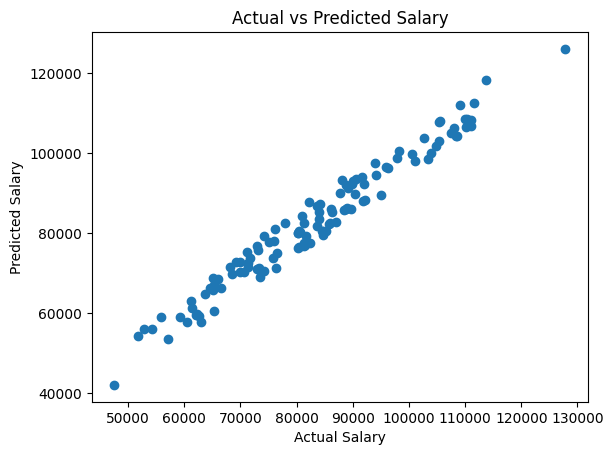

In [34]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [33]:
new_data = pd.DataFrame([{"Experience": 5,"Projects": 10,"PerformanceScore": 8,"Certifications": 3,"OvertimeHours": 20,"Education_Masters": 1,"Education_PhD": 0}])
pred_salary = model.predict(new_data)
print("Predicted Salary:", pred_salary[0])

Predicted Salary: 76626.3419608766
